# TUTORIAL: Introduction to real-time data assimilation
<script src='https://cdnjs.cloudflare.com/ajax/libs/mathjax/2.7.4/MathJax.js?config=default'></script>

* [What is real-time data assimilation?](#first)
    * [Sources of uncertainty in the assimilation framework](#second)
    * [Bayesian formulation of data assimilation](#fourth)
    * [Example of Bayesian update in a univariate case](#fourth-1)
    * [The real-time assimilation cycle](#cycle)
* [The linear-Gaussian setting: an exact solution](#linear)
* [Test case: a discrete damped oscillator](#testcase)
    * [The truth and the observations](#obs)
* [Real-time assimilation with the `KalmanFilter` estimator](#kf)
* [When is the exact Kalman filter not enough?](#takeaway)

This tutorial builds the Bayesian foundation — the maximum a posteriori (MAP) estimate and its sequential, univariate form — and closes the theory in the one setting where the Bayesian filter has an exact, closed-form solution: the classical **Kalman filter**, run with the repository's `KalmanFilter` estimator on a linear model. The [next tutorial](11_ensemble-DA_intro.ipynb) generalizes the update to nonlinear systems with ensembles.


# 1. What is Data Assimilation? <a name="first"></a>

Data assimilation is a technique for combining observational data and numerical models to improve our understanding and prediction of complex physical systems. It enables more accurate forecasts and decision-making across fields such as meteorology, hydrology, and oceanography. The overarching objective is to make *qualitatively* accurate numerical models more *quantitatively* correct.

The three main components of data assimilation are: a model of the physical system, observation data from sensors, and a statistical method, which integrates the data with the model to estimate the most likely system behavior. There are various statistical approaches to data assimilation, broadly classified into
- **Variational methods** (e.g., 4DVar), which assimlate all the data in one shot a posteriori. 
- **Sequential methods** (e.g., Kalman filters), which assimilate the sensors' measurement as they become availe, i.e., without the need to store and post-process the data. Therefore, sequential methods are often referred to as **real-time data assimilation**. This iterative procedure continuously collects data and updates model states and/or parameters accordingly.

Real-time data assimilation aims to estimate a physical quantity $\mathbf{d}^\dagger$ (i.e., the *truth*), which is unknown, by combining two sources of information:



## 1.1 Sources of Information and Uncertainty in the Assimilation Framework <a name="second"></a>

1. **Observational data** $\mathbf{d}$

These represent real-world measurements of observable quantities. The sensors are assumed to be **unbiased** but subject to **aleatoric uncertainty** (e.g., environmental or instrumental noise):

$$
\mathbb{E}[\mathbf{d}] = \mathbf{d}^\dagger, \quad \mathbf{d} \sim \mathcal{N}(\mathbf{d}^\dagger, \mathbf{C}_{dd}),
$$

where $\mathbf{C}_{dd}$ is a diagonal covariance matrix representing measurement errors.



2. **A physical numerical model** 

The model provides estimates of the system's internal state through a dynamical system

   $$
   \begin{aligned}
   \mathrm{d}\boldsymbol{\phi} &= \mathcal{F}\left(\boldsymbol{\phi}, \boldsymbol{\alpha} \right)\mathrm{d} t 
   \end{aligned}
   $$

   where
   - $\boldsymbol{\phi}$: state variables  
   - $\boldsymbol{\alpha}$: model parameters  
   - $\mathcal{F}$: nonlinear dynamics operator

In many cases, observations are not direct measurements of the state vector. Instead, a **measurement operator** $\mathbf{M}$ maps the model state to the observable space. We assume the model is unbiased in its predictions such that

$$
\mathbb{E}[\mathcal{M}(\boldsymbol{\phi})] = \mathbf{d}^\dagger.
$$

In practice, several sources of **aleatoric uncertainty** arise in the assimilation process:

- In the **model dynamics** $\mathcal{F}$, due to uncertain states $\boldsymbol{\phi}$ or parameters $\boldsymbol{\alpha}$,
- In the **measurement process** $\mathcal{M}$, due to discretization or model inadequacy.

We represent these uncertainties as deviations from the true values

$$
\boldsymbol{\phi} + \boldsymbol{\epsilon}_\phi = \boldsymbol{\phi}^\dagger, \quad
\boldsymbol{\alpha} + \boldsymbol{\epsilon}_\alpha = \boldsymbol{\alpha}^\dagger, \quad
\mathbf{M}\boldsymbol{\phi} + \boldsymbol{\epsilon}_q = \mathbf{d}^\dagger.
$$

## 1.2 Bayesian formulation of data assimilation <a class="anchor" id="fourth"></a>

To find the *analysis* state, i.e., the state which best captures the evolution of the system given the model $\mathcal{F}$ and the noisy, partial observations $\mathbf{d}$, we formulate a well-posed Bayesian maximum *a posteriori* estimation problem. 

### Probabilistic Framework

First, the state $\boldsymbol{\phi}$ and observations $\mathbf{d}$ are assumed to be realizations of their corresponding random variables, so that we can quantify our confidence by a probability measure $\mathcal{P}$. Accounting for uncertainty, the model becomes
$$
\begin{aligned}
\mathrm{d} \boldsymbol{\phi} &= \mathcal{F}\left(\boldsymbol{\phi}+\boldsymbol{\epsilon}_\phi, \boldsymbol{\alpha} +\boldsymbol{\epsilon}_\alpha\right)\mathrm{d} t 
\end{aligned}
$$
And the observations at time $t_k$ are modeled as:

$$
\mathbf{d} + \boldsymbol{\epsilon}_d = \mathbf{d}^\dagger, \quad \boldsymbol{\epsilon}_d \sim \mathcal{N}(\mathbf{0}, \mathbf{C}_{dd})
$$

with
$
\mathbb{E}(\mathbf{d}) = \mathbf{d}^\dagger
$
In this tutorial, we will assume that the parameters of the system are know, hence the only task is to infer the states of the system given some observations. This is, state estimation. 


### Markovian Prior

Second, we assume the model is Markovian, such that our prior on the state $\boldsymbol{\phi}_k = \boldsymbol{\phi}(t_k)$ follows:

$$
\mathcal{P}(\boldsymbol{\phi}_k \mid \boldsymbol{\phi}_{k-1}, \mathbf{F}) = \mathcal{P}(\boldsymbol{\phi}(t_k) \mid \boldsymbol{\phi}(t_1), \dots, \boldsymbol{\phi}_{k-1}, \mathbf{F})
$$
where $\mathcal{P}(\cdot|\cdot)$ denotes the conditional probability in which the quantity on the left is conditioned on the knowledge of the quantities on the right.

### Bayesian Update

Third, we update our confidence in the model predictions every time we have reference data from observations in a real-time framework. This is, when new observations $\mathbf{d}_k$ are available, our *prior* can be updated using Bayes' rule
$$
\begin{align}
\mathcal{P}(\boldsymbol{\phi}_k | \mathbf{d}_k,\mathbf{F}) = \frac{\mathcal{P}(\mathbf{d}_k | \boldsymbol{\phi}_k,  \mathbf{F}) \mathcal{P}(\boldsymbol{\phi}_k, \mathbf{F})}{\mathcal{P}(\mathbf{d}_k,  \mathbf{F})}, \quad \text{i.e.,} \quad
\texttt{posterior} = \dfrac{\texttt{prior}
\,\times\,
\texttt{likelihood}}
{\texttt{evidence}} 
\end{align}
$$
where the likelihood of the observations measures how consistent the predicted state $\boldsymbol{\phi}_k$ is with the new observation $\mathbf{d}_k$. We select the most probable value  (the mode) of $\boldsymbol{\phi}_k$ in the posterior as the best estimator of the state, i.e., the analysis. This is the <em >maximum a posteriori </em>  approach, which is a well-posed approach in inverse problems.

### Gaussian assumption
We assume a Gaussian prior and likelihood, i.e.,

$$
\boldsymbol{\phi}^f \sim \mathcal{N}(\boldsymbol{\phi}, \mathbf{C}_{\phi\phi}^f), \quad \mathbf{d} \sim \mathcal{N}(\mathbf{M}\boldsymbol{\phi}, \mathbf{C}_{dd})
$$

where:
- $\mathbf{C}_{\phi\phi}^f$ and $\mathbf{C}_{dd}$ are the forecast and measurement error covariances, respectively,
- the superscript $f$ indicates 'forecast'. 

With these assumptions, the posterior will also be Gaussian.

### Maximum a Posteriori (MAP) Estimation

Taking a maximum a posteriori approach:

$$
\boldsymbol{\phi}^a = \underset{\boldsymbol{\phi}}{\text{argmax}}\, \mathcal{P}(\boldsymbol{\phi} \mid \mathbf{d}, \mathbf{F}) = \underset{\boldsymbol{\phi}}{\text{argmin}}\, \mathcal{J}(\boldsymbol{\phi})
$$

where the cost function to minimize is:

$$
\mathcal{J}(\boldsymbol{\phi}) = (\boldsymbol{\phi}^f - \boldsymbol{\phi})^\top (\mathbf{C}_{\phi\phi}^f)^{-1} (\boldsymbol{\phi}^f - \boldsymbol{\phi}) + (\mathbf{d} - \mathbf{M}\boldsymbol{\phi})^\top \mathbf{C}_{dd}^{-1} (\mathbf{d} - \mathbf{M}\boldsymbol{\phi})
$$



## 1.3 Example of Bayesian update in a univariate case <a class="anchor" id="fourth-1"></a>

In [1]:
import numpy as np    
from scipy import stats, linalg
import matplotlib.pyplot as plt


x_grid = np.linspace(-10, 10, 101)

def pdf_Normal(mu, std):
    return stats.norm.pdf(x_grid, loc=mu, scale=std)
    
def Bayes_rule(prior, likelihood):
    posterior = prior * likelihood       
    return posterior / (np.sum(posterior) * (x_grid[1] - x_grid[0]))


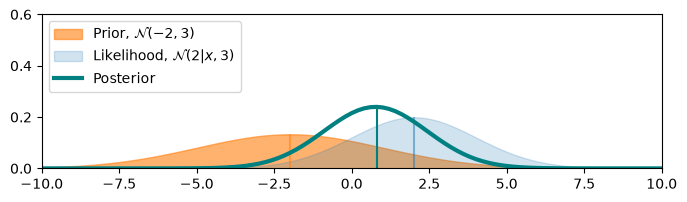

In [2]:
# Initialise prior
prior_mu, prior_std = -2, 3
prior_vals = pdf_Normal(mu=prior_mu, std=prior_std)

# Initialise likelihood
def likelihood_func(observation, method=pdf_Normal, likelihood_std=2):
    return method(mu=observation, std=likelihood_std)

# Observe a data point d and compute the posterior
d = 2
likelihood_vals = likelihood_func(observation=d)     

# Compute the new posterior
posterior_vals = Bayes_rule(prior_vals, likelihood_vals)

# Visualize

plt.figure(figsize=(8, 2))

plt.fill_between(x_grid, prior_vals,  color='tab:orange', alpha=0.6, label='Prior, $\\mathcal{N}$'+f'$({prior_mu}, {prior_std})$')
plt.vlines(prior_mu,  ymin=0, ymax=np.max(prior_vals), color='tab:orange', alpha=0.5)

plt.fill_between(x_grid, likelihood_vals, color='tab:blue', alpha=0.2,  label='Likelihood, $\\mathcal{N}$'+f'$({d}|x, {prior_std})$')
plt.vlines(d,  ymin=0, ymax=np.max(likelihood_vals), color='tab:blue', alpha=0.5)

plt.plot(x_grid, posterior_vals,  color='teal', lw=3 ,label='Posterior')
plt.vlines(x_grid[np.argmax(posterior_vals)], ymin=0, ymax=np.max(posterior_vals), color='teal')
plt.gca().set(ylim=(0, 0.6), xlim=(-10, 10))
plt.legend(loc="upper left");




<br />

___

#### Exercise
<em><font color=#7CB9E8>  What happens if the variance of the prior is small? What if the prior or likelihood functions are not Gaussian?
___



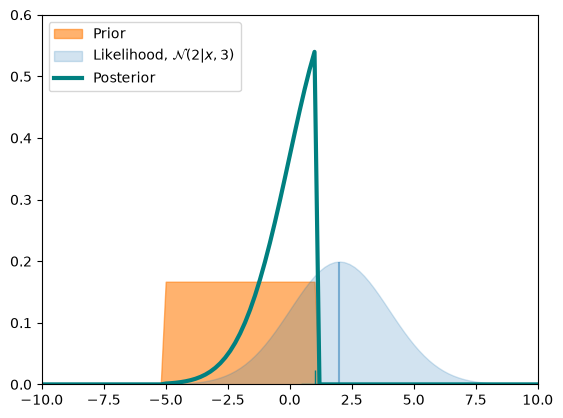

In [3]:
# prior_vals_2 = pdf_Normal(mu=prior_mu, std=prior_std) + pdf_Normal(mu=7, std=1)
prior_vals_2 = stats.uniform(loc=-5, scale=6).pdf(x_grid)

posterior_vals_2 = Bayes_rule(prior_vals_2, likelihood_vals)

# Visualize
plt.fill_between(x_grid, prior_vals_2,  color='tab:orange', alpha=0.6, label='Prior')
plt.fill_between(x_grid, likelihood_vals, color='tab:blue', alpha=0.2,  label='Likelihood, $\\mathcal{N}$'+f'$({d}|x, {prior_std})$')
plt.vlines(d,  ymin=0, ymax=np.max(likelihood_vals), color='tab:blue', alpha=0.5)
plt.plot(x_grid, posterior_vals_2,  color='teal', lw=3 ,label='Posterior')
plt.plot(x_grid[np.argmax(posterior_vals_2)], 0, '+', markersize=20, color='teal')
plt.gca().set(ylim=(0, 0.6), xlim=(-10, 10))
plt.legend(loc="upper left");

### Sequential update
In real-time data assimilation, we perform this update sequentially, using the posterior as the new prior:

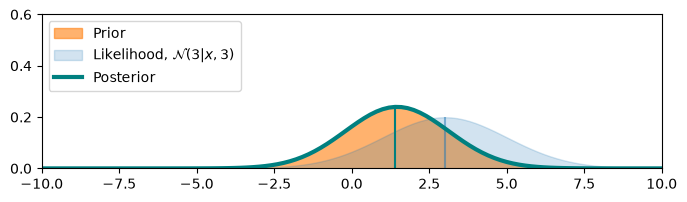

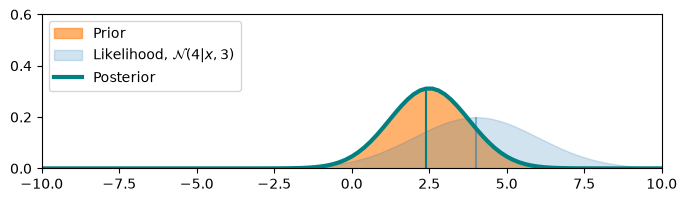

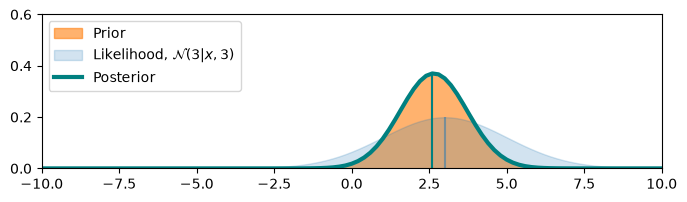

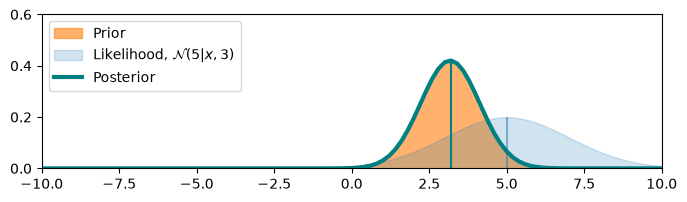

In [4]:
observation_stream = [3,4,3,5]

prior_mu, prior_std = -2, 3
prior_vals = pdf_Normal(mu=prior_mu, std=prior_std)

for d in observation_stream:
    
    likelihood_vals = likelihood_func(observation=d)            # Compute the likelihood od the observation
    posterior_vals = Bayes_rule(prior_vals, likelihood_vals)    # Compute the new posterior
    prior_vals = posterior_vals                                 # Use the posterior as the new prior

    plt.figure(figsize=(8, 2))
    plt.fill_between(x_grid, prior_vals,  color='tab:orange', alpha=0.6, label='Prior') # Use the posterior as the new prior
    plt.vlines(x_grid[np.argmax(prior_vals)],  ymin=0, ymax=np.max(prior_vals), color='tab:orange', alpha=0.5)
    plt.fill_between(x_grid, likelihood_vals, color='tab:blue', alpha=0.2,  label='Likelihood, $\\mathcal{N}$'+f'$({d}|x, {prior_std})$')
    plt.vlines(d,  ymin=0, ymax=np.max(likelihood_vals), color='tab:blue', alpha=0.5)
    plt.plot(x_grid, posterior_vals,  color='teal', lw=3,label='Posterior')
    plt.vlines(x_grid[np.argmax(posterior_vals)],  ymin=0, ymax=np.max(posterior_vals), color='teal')
    plt.gca().set(ylim=(0, 0.6), xlim=(-10, 10))
    plt.legend(loc="upper left");




<br />

___


####  Exercise
<em> <font color=#7CB9E8> <em>
Given Gaussian prior $\boldsymbol{\phi} \sim \mathcal{N}(\boldsymbol{\phi}, \mathbf{C}_{\phi\phi})$ and a likelihood $
\mathbf{d}|\boldsymbol{\phi}) \sim \mathcal{N}(\mathbf{d}, \mathbf{C}_{dd})$,  show that the posterior is also a Gaussian. Hint: the  probability density function of a Gaussian distribution of mean $\boldsymbol{\mu}$ and covariance $\mathbf{C}$ is
$$
f(\boldsymbol{\phi}) = \dfrac{1}{\sqrt{(2\pi)^k |\mathbf{C}|}}\exp\left(-\frac{1}{2} \left(\boldsymbol{\phi} - \boldsymbol{\mu}\right)^\mathrm{T} \mathbf{C}^{-1} \left(\boldsymbol{\phi} - \boldsymbol{\mu}\right)\right)
$$ </em>


<br />

___



## 1.4 The real-time assimilation cycle <a name="cycle"></a>

In a nutshell, the assimilation process consists of repeating sequentially the following three steps:
1. <em>Forecast</em>: propagate the numerical model in time until <strong><font color="#24678d">observation</font></strong> data become available. The model provides an estimate of the observed physical quantity, which is known as the <strong><font color="#e0915c">forecast</font></strong>.

2. <em>Analysis</em>: combine <span>optimally</span> the <strong><font color="#e0915c">forecast</font></strong> with the <strong><font color="#24678d">observations</font></strong>. This results in an improved estimate of the physical quantity, which is more accurate than the forecast, and it is  known as the <strong><font color="#76cae9">analysis</font></strong>.

3. <em>Update</em>: the <strong><font color="#76cae9">analysis</font></strong> state becomes the initial condition for the next forecast step.

<a><img src="../../../docs/figs/DA/Real-time-DA.gif" width=800px></a> 


# 2. The linear-Gaussian setting: an exact solution <a name="linear"></a>

When the model is *linear* and the uncertainties are *Gaussian*, the sequential Bayesian problem above has an exact, closed-form solution — the classical **Kalman filter** (Kalman, 1960) — and the update can be written directly on the mean and covariance. Consider a discrete-time linear model observed through a linear measurement operator with Gaussian noise,

$$
\boldsymbol{\psi}_{k+1} = \mathbf{F}\,\boldsymbol{\psi}_k, \qquad
\mathbf{d}_k = \mathbf{M}\boldsymbol{\psi}_k^\dagger + \boldsymbol{\epsilon}_d, \qquad
\boldsymbol{\epsilon}_d \sim \mathcal{N}(\mathbf{0}, \mathbf{C}_{dd}).
$$

If the prior on the state is Gaussian, it *stays* Gaussian forever: a linear map of a Gaussian is Gaussian, and the product of Gaussian prior and Gaussian likelihood (the Bayesian update of Section 1) is again Gaussian. The full posterior is therefore described exactly by its mean $\boldsymbol{\psi}$ and covariance $\mathbf{C}_{\psi\psi}$, and Bayes' rule reduces to a closed-form recursion on these two moments:

**Forecast** (between observations):
$$
\boldsymbol{\psi}^\mathrm{f} = \mathbf{F}\,\boldsymbol{\psi}^\mathrm{a}, \qquad
\mathbf{C}^\mathrm{f}_{\psi\psi} = \mathbf{F}\,\mathbf{C}^\mathrm{a}_{\psi\psi}\,\mathbf{F}^\mathrm{T} + \mathbf{Q}.
$$

**Analysis** (when a datum $\mathbf{d}$ arrives):
$$
\mathbf{K} = \mathbf{C}^\mathrm{f}_{\psi\psi}\mathbf{M}^\mathrm{T}
\left(\mathbf{M}\mathbf{C}^\mathrm{f}_{\psi\psi}\mathbf{M}^\mathrm{T} + \mathbf{C}_{dd}\right)^{-1},
$$
$$
\boldsymbol{\psi}^\mathrm{a} = \boldsymbol{\psi}^\mathrm{f} + \mathbf{K}\left(\mathbf{d} - \mathbf{M}\boldsymbol{\psi}^\mathrm{f}\right), \qquad
\mathbf{C}^\mathrm{a}_{\psi\psi} = \left(\mathbb{I} - \mathbf{K}\mathbf{M}\right)\mathbf{C}^\mathrm{f}_{\psi\psi}.
$$

The Kalman gain $\mathbf{K}$ is the same one we obtained from the MAP cost function of Section 1 — but here the covariance is propagated *exactly* through the dynamics instead of being estimated from samples. In the linear-Gaussian setting the Kalman filter **is** the Bayesian filter: no sampling error, no inflation, no ensemble collapse. In exchange it requires (i) linear (or linearized) dynamics and (ii) storing and propagating the full $N \times N$ covariance — the two requirements that ensemble methods drop.

In [5]:
from romda.models.data_driven import LinearModel
from romda.estimators import KalmanFilter
from romda.observations import Observations

from romda.plotting import Palette   # one color per entity, shared by all romda figures
c_truth, c_obs = Palette.TRUE, Palette.OBS
c_kf, c_a = Palette.UNBIASED, Palette.BIASED    # filter mean / analysis


# 3. Test case: a discrete damped oscillator <a name="testcase"></a>

`LinearModel` (in `romda.models.data_driven.linear_model`) is the simplest forecast model in the repository: the discrete map $\boldsymbol{\psi}_{k+1} = \mathbf{F}\boldsymbol{\psi}_k$, advanced by the `DiscreteIntegrator` strategy (it implements `time_step` rather than a continuous `time_derivative`, so there is no ODE solver — and no multiprocessing — involved). We choose $\mathbf{F}$ as a rotation combined with a mild decay,

$$
\mathbf{F} = r\begin{bmatrix}\cos\theta & -\sin\theta\\ \sin\theta & \cos\theta\end{bmatrix},
\qquad r = 0.998, \quad \theta = 2\pi/40,
$$

i.e., a sampled damped harmonic oscillator with a period of 40 steps and a slowly decaying amplitude. Only the first component is observed, $\mathbf{M} = [1,\ 0]$, so the filter must reconstruct the unobserved $x_1$ from measurements of $x_0$ alone.

In [6]:
dt = 1.0
theta = 2 * np.pi / 40            # oscillation period: 40 steps
r = 0.998                         # mild damping
F = r * np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta),  np.cos(theta)]])
M_obs = np.array([[1.0, 0.0]])    # observe only the first component
Nphi, Nq = F.shape[0], M_obs.shape[0]

Nt_total = 128

true_model = LinearModel(F=F, M_obs=M_obs, psi0=np.array([3.0, 0.0]), dt=dt)

psi, t = true_model.time_integrate(Nt=Nt_total)
true_model.update_history(psi, t)

y_true = true_model.hist[:, :Nphi, 0] @ M_obs.T    # (Nt+1, Nq) true observable trajectory

## 3.1 The truth and the observations <a name="obs"></a>

`Observations` samples noisy measurements from the truth. Since `LinearModel.get_observables` only maps the *current* state (it ignores its `Nt` argument), we hand `Observations` the observable trajectory as arrays (`model=None` path) instead of the model itself — the same interface you would use with experimental data.

With additive Gaussian noise (`'gauss, add'`), `Observations` draws $\epsilon \sim \mathcal{N}(0, \texttt{noise\_level}^2)$ and scales it by $\max_t |y|$, so the measurement-error standard deviation is $\sigma_d = \texttt{noise\_level} \cdot \max_t|y^\dagger|$. In a twin experiment we know this exactly, so the Kalman filter can be given the *true* observation-noise covariance $\mathbf{C}_{dd} = \sigma_d^2\,\mathbb{I}$.

...Adding noise: gauss, add with level 0.1.
Number of observations: 13,  sigma_d = [0.3]


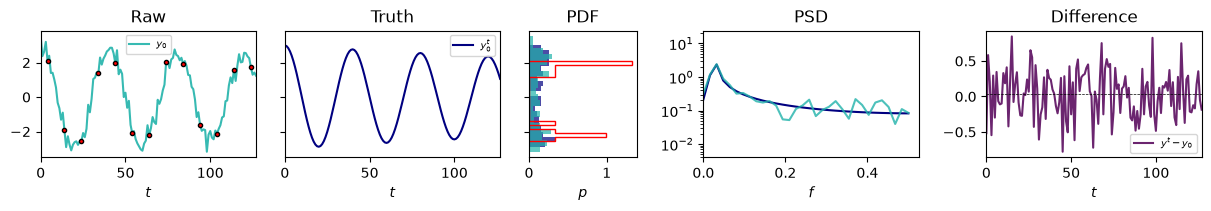

In [7]:
Nt_obs = 10        # observe every 10th model step
truth = Observations(y_true=y_true, t_true=true_model.hist_t,
                     t_start=4.0, t_stop=124.0, Nt_obs=Nt_obs,
                     add_noise=True, noise_type='gauss, add', noise_level=0.1)

sigma_d = truth.noise_level * np.max(np.abs(truth.y_true[..., 0]), axis=0)
Cdd = np.diag(sigma_d ** 2)
print(f"Number of observations: {len(truth.t_obs)},  sigma_d = {sigma_d}")

Observations.plot_truth(truth, window=float(Nt_total))

# 4. Real-time assimilation with the `KalmanFilter` estimator <a name="kf"></a>

`KalmanFilter` (in `romda.estimators.deterministic`) is a `DeterministicEstimator`: unlike the ensemble estimators, it owns the mean $\boldsymbol{\psi}$ and the covariance $\mathbf{C}_{\psi\psi}$ explicitly, and the model is only used to advance the mean. The constructor takes:

- `N`, `Nq` — state and observable dimensions;
- `psi0`, `Cpp0` — the Gaussian prior $\mathcal{N}(\boldsymbol{\psi}_0, \mathbf{C}_{\psi\psi,0})$;
- `Cdd` — the default observation-noise covariance;
- `M` — the measurement operator, here of shape $(N_q, N_\phi)$. We pass it explicitly: the default read from `model.M` is the augmented-state operator $[\mathbf{0},\ \mathbb{I}]$ built for the observable-augmented ensembles, which is not what we want on the plain state;
- `model` — a `Model` instance used for the mean forecast. (Alternatively, `model=None` with `F=...` runs the filter purely matrix-driven, one application of $\mathbf{F}$ per step);
- `F_jac` — the Jacobian of **one model step**, used in the covariance propagation $\mathbf{C}^\mathrm{f} = \mathbf{F}_\mathrm{jac}\mathbf{C}^\mathrm{a}\mathbf{F}_\mathrm{jac}^\mathrm{T} + \mathbf{Q}$, applied once per step spanned by each `forecast_step`. It defaults to the model's own transition matrix (`model.F`) when the model is linear — as here, so we do not pass it — and to the identity for a nonlinear model without one.

The assimilation loop is the same for every estimator in the repository: `forecast_step(t_end)` followed by `analysis_step(d, Cdd)`.

In [8]:
psi0_prior = np.array([2.0, 1.0])       # biased initial guess (the truth starts at [3, 0])
Cpp0 = 1.5 ** 2 * np.eye(Nphi)          # prior covariance at t = 0

kf_model = LinearModel(F=F, M_obs=M_obs, psi0=psi0_prior, dt=dt)

kf = KalmanFilter(N=Nphi, Nq=Nq, Cdd=Cdd,
                  psi0=psi0_prior, Cpp0=Cpp0,
                  M=M_obs,
                  model=kf_model)

In [9]:
sig_f, sig_a, psi_a = [], [], []    # forecast/analysis stds and analysis mean at the observation times

for d, t_d in zip(truth.y_obs, truth.t_obs):
    kf.forecast_step(t_end=t_d)
    sig_f.append(np.sqrt(np.diag(kf.Cpp)))    # the covariance has no public accessor (yet)
    kf.analysis_step(d=d, Cdd=Cdd)
    sig_a.append(np.sqrt(np.diag(kf.Cpp)))
    psi_a.append(kf.current_state.copy())

sig_f, sig_a, psi_a = np.array(sig_f), np.array(sig_a), np.array(psi_a)
print(f"Final analysis state: {kf.current_state.round(3)}  at t = {kf.current_time}")
print(f"Final posterior std:  {np.sqrt(np.diag(kf.Cpp)).round(3)}")

Final analysis state: [1.835 1.568]  at t = 124.0
Final posterior std:  [0.1   0.108]


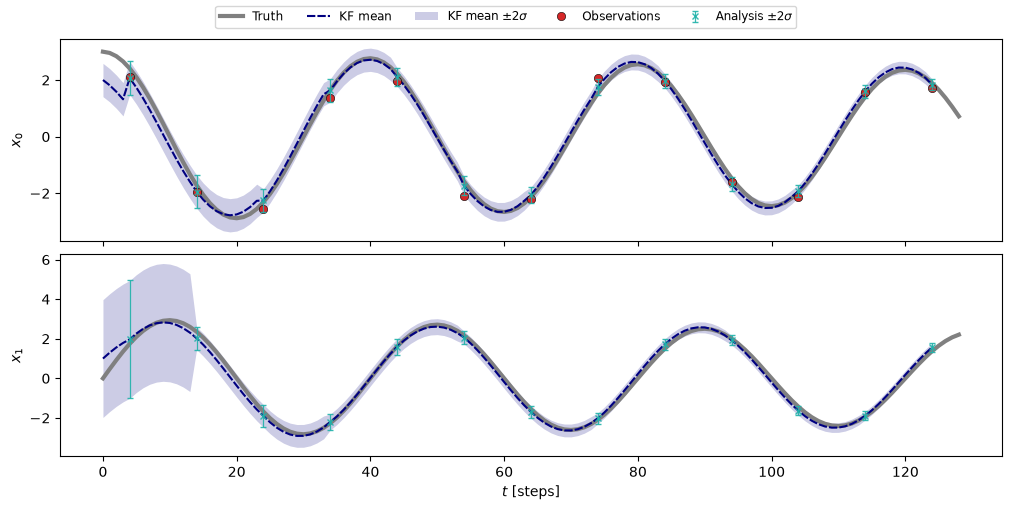

In [10]:
# The analysed mean is written back into the model history, so kf.model.hist is
# the mean trajectory with the analysis jumps at the observation times.

t_kf, psi_kf = kf.model.hist_t, kf.model.hist[:, :, 0]

# Build a piecewise-constant analysis spread on the model timeline:
# at each model time, use the latest available analysis sigma.

obs_idx = np.searchsorted(truth.t_obs, t_kf, side='right') - 1
obs_idx = np.clip(obs_idx, 0, len(truth.t_obs) - 1)

fig, axs = plt.subplots(2, 1, figsize=(10, 5), sharex=True, layout='constrained')
for ii, ax in enumerate(axs):
    sigma_piecewise = sig_a[obs_idx, ii]
    ax.plot(true_model.hist_t, true_model.hist[:, ii, 0], color=c_truth, lw=3, label='Truth')
    ax.plot(t_kf, psi_kf[:, ii], color=c_kf, lw=1.5, dashes=(4, 1), label='KF mean')
    ax.fill_between(t_kf, psi_kf[:, ii] - 2 * sigma_piecewise, psi_kf[:, ii] + 2 * sigma_piecewise,
                    color=c_kf, alpha=0.2, lw=0, label='KF mean $\\pm 2\\sigma$')

    err_label = 'Analysis $\\pm 2\\sigma$' if ii == 0 else None
    ax.errorbar(truth.t_obs, psi_a[:, ii], yerr=2 * sig_a[:, ii], fmt='x', ms=5, lw=2,
                mfc=c_a, mec=c_a, ecolor=c_a, elinewidth=0.9, capsize=2,
                alpha=0.9, label=err_label, zorder=5)
    ax.set(ylabel=true_model.state_labels[ii])
axs[0].plot(truth.t_obs, truth.y_obs[:, 0], 'o', ms=6, color=c_obs, mec='k', mew=0.4, lw=0, label='Observations')
fig.legend(*axs[0].get_legend_handles_labels(), loc='outside upper center', fontsize='small', ncols=5)
axs[-1].set(xlabel='$t$ [steps]');

The filter locks onto the truth within a few analyses — including the component $x_1$ that is *never observed*: $\mathbf{F}$ couples the two components, so the propagated covariance carries their correlation and the Kalman gain distributes each innovation onto both. The $\pm 2\sigma$ envelope contracts accordingly.

A defining property of the Kalman filter is that the covariance recursion does not depend on the data — only on $\mathbf{F}$, $\mathbf{M}$, $\mathbf{C}_{dd}$, and $\mathbf{C}_{\psi\psi,0}$. The uncertainty therefore follows a deterministic *sawtooth*: it grows by $\mathbf{F}\mathbf{C}\mathbf{F}^\mathrm{T}$ between observations and contracts at each update, converging to the fixed point of the discrete algebraic Riccati equation (i.e., to a steady-state Kalman gain).

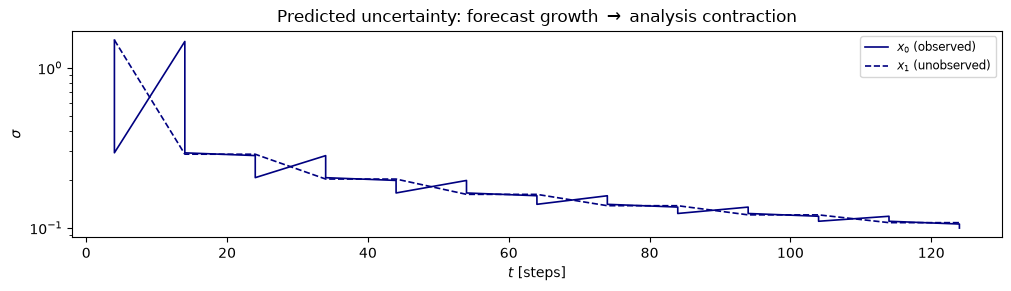

In [11]:
t_saw = np.repeat(truth.t_obs, 2)   # interleave forecast/analysis values -> uncertainty sawtooth

fig, ax = plt.subplots(figsize=(10, 2.8), layout='constrained')
for ii, ls, lbl in zip(range(Nphi), ['-', '--'], ['$x_0$ (observed)', '$x_1$ (unobserved)']):
    saw = np.column_stack((sig_f[:, ii], sig_a[:, ii])).ravel()
    ax.semilogy(t_saw, saw, ls, color=c_kf, lw=1.2, label=lbl)
ax.set(xlabel='$t$ [steps]', ylabel='$\\sigma$',
       title='Predicted uncertainty: forecast growth $\\to$ analysis contraction')
ax.legend(loc='upper right', fontsize='small');

# 5. When is the exact Kalman filter not enough? <a name="takeaway"></a>

On this problem the Kalman filter is unbeatable — it *is* the exact Bayesian filter, with no sampling noise and nothing to tune. But its recursion relies on linear dynamics, on a tangent-linear model (the Jacobian $\mathbf{F}_\mathrm{jac}$), and on storing and propagating the full $N \times N$ covariance — three requirements that rule it out for the nonlinear, high-dimensional systems this repository targets. **Ensemble methods** drop all three at once by replacing the exact covariance recursion with the sample statistics of $m$ model runs: they are the subject of the [next tutorial](11_ensemble-DA_intro.ipynb).

<br />

___

#### Exercises
<em><font color=#7CB9E8> Double the sensor noise (`noise_level=0.2`). How do the envelope and the uncertainty sawtooth change? What changes if you observe both components, $\mathbf{M} = \mathbb{I}$?</font></em>

<em><font color=#7CB9E8> Verify that the posterior covariance reaches a steady state by comparing `sig_a[-1]` and `sig_a[-2]` — this is the fixed point of the discrete algebraic Riccati equation, and it does not depend on `Cpp0`.</font></em>

<em><font color=#7CB9E8> Make the dynamics unstable, $r = 1.002$. Can the filter still track the truth? What happens as you increase the gap `Nt_obs` between observations?</font></em>

___
